# Anylisis with spherical harmonics

In [1]:
import numpy as np 
import pandas as pd 
from scipy.special import sph_harm
from helpers import geometry
from helpers import sampler
from helpers import coord
from helpers import rwhist, collision, rwbeams, sphericalharmonics, utils


# Copyright (C) 2026 Clara Jourdan (Instituto de Fusión Nuclear Guillermo Velarde, Universidad Politécnica de Madrid) hereby claims all interest in program "coord"
# Module 'sampler' loaded successfully.


# Module omega geometry loaded (Author: Clara Jourdan)


# Copyright (C) 2026 Manuel Cotelo Ferreiro (Instituto de Fusión Nuclear Guillermo Velarde, Universidad Politécnica de Madrid) hereby claims all interest in program "hist"
# Copyright (C) 2026 Clara Jourdan (Instituto de Fusión Nuclear Guillermo Velarde, Universidad Politécnica de Madrid) hereby claims all interest in program "beams"
# Copyright (C) 2026 Clara Jourdan (Instituto de Fusión Nuclear Guillermo Velarde, Universidad Politécnica de Madrid) hereby claims all interest in program "omega geometry"
# Copyright (C) 2026 Clara Jourdan (Instituto de Fusión Nuclear Guillermo Velarde, Universidad Politécnica de Madrid) hereby claims all interest in program "omega geometry"


### Reading the histogram data

In [2]:
# Recharge la grille et les valeurs d'intensité
df_omega = rwbeams.read_beams("omega60_master_config.xlsx")

theta_edges, phi_edges, hs_reloaded = rwhist.read_histogram("omega60_illumination_map.csv")


## First way 
Compute of spherical coefficient

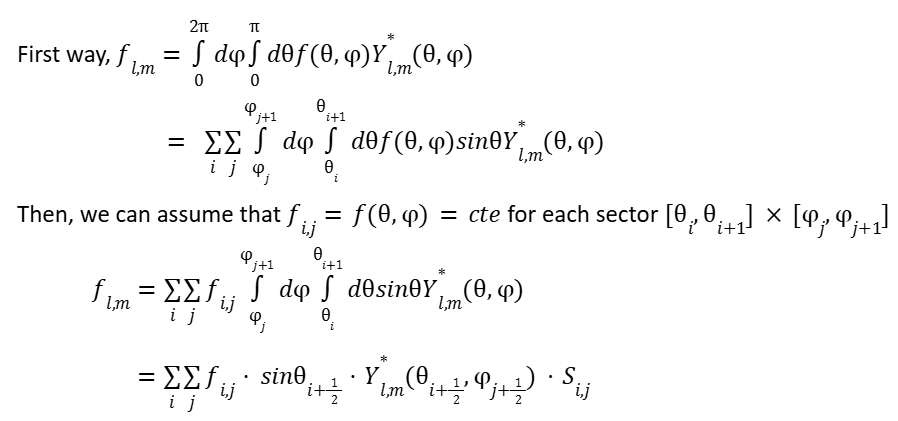

Table with the spherical harmonics calculated with method A

In [3]:
n_theta, n_phi = 50, 50
theta_edges = np.linspace(0, np.pi, n_theta + 1)
phi_edges = np.linspace(0, 2*np.pi, n_phi + 1)


sphericalharmonics.analyze_histogram_A(hs_reloaded, theta_edges, phi_edges, Lmax=6)


=== SPHERICAL HARMONIC ANALYSIS OF THE ACTUAL HISTOGRAM ===


================ NORMALIZED COEFFICIENTS f_{lm} =================

  l    m        Re(f_lm)        Im(f_lm)          |f_lm|   |f_lm|/|f_00|
---------------------------------------------------------------------------
  0    0    8.462712e+03    0.000000e+00    8.462712e+03    1.000000e+00
  1   -1    1.047651e+01   -3.078740e+00    1.091952e+01    1.290310e-03
  1    0    1.608396e+01    0.000000e+00    1.608396e+01    1.900568e-03
  1    1   -1.047651e+01   -3.078740e+00    1.091952e+01    1.290310e-03
  2   -2    2.439637e+01    1.736563e+00    2.445810e+01    2.890102e-03
  2   -1    1.409463e+01   -2.513020e+00    1.431690e+01    1.691763e-03
  2    0    1.043845e+00    0.000000e+00    1.043845e+00    1.233464e-04
  2    1   -1.409463e+01   -2.513020e+00    1.431690e+01    1.691763e-03
  2    2    2.439637e+01   -1.736563e+00    2.445810e+01    2.890102e-03
  3   -3    1.068272e+01   -8.305153e+00    1.353130e+01    1.59

{(0, 0): np.complex128(8462.711761063274+0j),
 (1, -1): np.complex128(10.476510898662111-3.0787401653589868j),
 (1, 0): np.complex128(16.083958468723267+0j),
 (1, 1): np.complex128(-10.476510898662111-3.0787401653589868j),
 (2, -2): np.complex128(24.396372260545505+1.7365632014286314j),
 (2, -1): np.complex128(14.094626172415943-2.5130202141288436j),
 (2, 0): np.complex128(1.0438449904777372+0j),
 (2, 1): np.complex128(-14.094626172415943-2.5130202141288436j),
 (2, 2): np.complex128(24.396372260545505-1.7365632014286314j),
 (3, -3): np.complex128(10.682716907191564-8.305153007849002j),
 (3, -2): np.complex128(7.430070688565962-9.871080325393859j),
 (3, -1): np.complex128(23.67113013066525-2.2179006107962493j),
 (3, 0): np.complex128(17.263482813617657+0j),
 (3, 1): np.complex128(-23.67113013066525-2.2179006107962493j),
 (3, 2): np.complex128(7.430070688565962+9.871080325393859j),
 (3, 3): np.complex128(-10.682716907191564-8.305153007849002j),
 (4, -4): np.complex128(12.708323721233452+

## Second way 

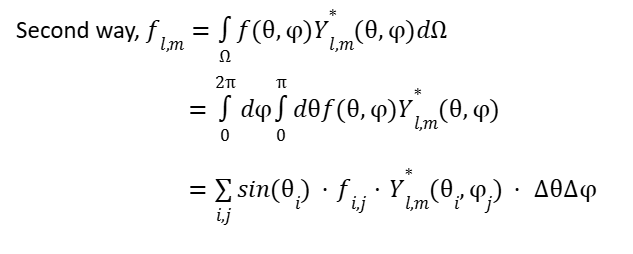

Calculation of spherical harmonics

Organized coefficient 

In [4]:
n_theta, n_phi = 50, 50
theta_edges = np.linspace(0, np.pi, n_theta + 1)
phi_edges = np.linspace(0, 2*np.pi, n_phi + 1)

sphericalharmonics.analyze_histogram_B(hs_reloaded, theta_edges, phi_edges, Lmax=6)


=== SPHERICAL HARMONIC ANALYSIS OF THE ACTUAL HISTOGRAM ===


================ NORMALIZED COEFFICIENTS f_{lm} =================

  l    m        Re(f_lm)        Im(f_lm)          |f_lm|   |f_lm|/|f_00|
---------------------------------------------------------------------------
  0    0    8.464104e+03    0.000000e+00    8.464104e+03    1.000000e+00
  1   -1    1.047823e+01   -3.079247e+00    1.092132e+01    1.290310e-03
  1    0    1.608660e+01    0.000000e+00    1.608660e+01    1.900568e-03
  1    1   -1.047823e+01   -3.079247e+00    1.092132e+01    1.290310e-03
  2   -2    2.440039e+01    1.736849e+00    2.446212e+01    2.890102e-03
  2   -1    1.409694e+01   -2.513434e+00    1.431926e+01    1.691763e-03
  2    0    1.044017e+00    0.000000e+00    1.044017e+00    1.233464e-04
  2    1   -1.409694e+01   -2.513434e+00    1.431926e+01    1.691763e-03
  2    2    2.440039e+01   -1.736849e+00    2.446212e+01    2.890102e-03
  3   -3    1.068447e+01   -8.306519e+00    1.353352e+01    1.59

{(0, 0): np.complex128(8464.103981656643+0j),
 (1, -1): np.complex128(10.478234414083321-3.079246656136604j),
 (1, 0): np.complex128(16.08660447851753+0j),
 (1, 1): np.complex128(-10.478234414083321-3.079246656136604j),
 (2, -2): np.complex128(24.40038576506122+1.7368488875208272j),
 (2, -1): np.complex128(14.096944912480343-2.5134336369882107j),
 (2, 0): np.complex128(1.0440167158685654+0j),
 (2, 1): np.complex128(-14.096944912480343-2.5134336369882107j),
 (2, 2): np.complex128(24.40038576506122-1.7368488875208272j),
 (3, -3): np.complex128(10.68447434604822-8.306519308081516j),
 (3, -2): np.complex128(7.431293026950446-9.872704240008524j),
 (3, -1): np.complex128(23.675024323894124-2.2182654828361876j),
 (3, 0): np.complex128(17.266322869732903+0j),
 (3, 1): np.complex128(-23.675024323894124-2.2182654828361876j),
 (3, 2): np.complex128(7.431293026950446+9.872704240008524j),
 (3, 3): np.complex128(-10.68447434604822-8.306519308081516j),
 (4, -4): np.complex128(12.71041439742514+15.331

## Reconstruction error

In [5]:
# Lancement de l'analyse
resultats = sphericalharmonics.analyze_model_fidelity(hs_reloaded, theta_edges, phi_edges, Lmax=6)

# Présentation propre sous forme de tableau
summary = pd.DataFrame({
    'Indicateur': ['Erreur Moyenne <e_ij>', 'Erreur Maximale (max)'],
    'Valeur (%)': [f"{resultats['mean_error']:.4f} %", f"{resultats['max_error']:.2f} %"]
})

print("### RÉSUMÉ DE LA FIDÉLITÉ DU MODÈLE ###")
display(summary)

### RÉSUMÉ DE LA FIDÉLITÉ DU MODÈLE ###


,Indicateur,Valeur (%)
0,Erreur Moyenne <e_ij>,21.9006 %
1,Erreur Maximale (max),465.99 %


## Comparaison of the two methods

In [6]:
def run_comparison(hist, theta_edges, phi_edges, Lmax=6):
    # 1. Execute both methods
    coeffs_A = sphericalharmonics.compute_sph_coeffs_A(hist, theta_edges, phi_edges, Lmax)
    coeffs_B = sphericalharmonics.compute_sph_coeffs_B(hist, theta_edges, phi_edges, Lmax)

    # 2. Display the table header
    print(f"{'l':>2} {'m':>3} | {'Method A (Re)':>13} | {'Method B (Re)':>13} | {'Difference':>13}")
    print("-" * 65)

    differences = []

    # 3. Compare each (l, m) pair
    # We use .real to compare the primary magnitude of the coefficients
    for key in sorted(coeffs_A.keys()):
        val_A = coeffs_A[key].real
        val_B = coeffs_B[key].real
        diff = abs(val_A - val_B)
        differences.append(diff)
        
        print(f"{key[0]:2d} {key[1]:3d} | {val_A:13.6e} | {val_B:13.6e} | {diff:13.6e}")

    # 4. Final statistics
    print("-" * 65)
    print(f"Mean Error: {np.mean(differences):.2e}")
    print(f"Maximum Error: {np.max(differences):.2e}")


run_comparison(hs_reloaded, theta_edges, phi_edges, Lmax=6)

 l   m | Method A (Re) | Method B (Re) |    Difference
-----------------------------------------------------------------
 0   0 |  8.462712e+03 |  8.464104e+03 |  1.392221e+00
 1  -1 |  1.047651e+01 |  1.047823e+01 |  1.723515e-03
 1   0 |  1.608396e+01 |  1.608660e+01 |  2.646010e-03
 1   1 | -1.047651e+01 | -1.047823e+01 |  1.723515e-03
 2  -2 |  2.439637e+01 |  2.440039e+01 |  4.013505e-03
 2  -1 |  1.409463e+01 |  1.409694e+01 |  2.318740e-03
 2   0 |  1.043845e+00 |  1.044017e+00 |  1.717254e-04
 2   1 | -1.409463e+01 | -1.409694e+01 |  2.318740e-03
 2   2 |  2.439637e+01 |  2.440039e+01 |  4.013505e-03
 3  -3 |  1.068272e+01 |  1.068447e+01 |  1.757439e-03
 3  -2 |  7.430071e+00 |  7.431293e+00 |  1.222338e-03
 3  -1 |  2.367113e+01 |  2.367502e+01 |  3.894193e-03
 3   0 |  1.726348e+01 |  1.726632e+01 |  2.840056e-03
 3   1 | -2.367113e+01 | -2.367502e+01 |  3.894193e-03
 3   2 |  7.430071e+00 |  7.431293e+00 |  1.222338e-03
 3   3 | -1.068272e+01 | -1.068447e+01 |  1.757439e-03

## Optimisation

Creation of the class

In [7]:
class Optimisationharmonics:
    def __init__(self, num_rays_per_beam=1000, target_radius=0.001):
        self.target_radius = target_radius
        self.num_rays_per_beam = num_rays_per_beam
        self.beams_df = geometry.get_omega60_dataframe()
        
        # Paramètres de résolution
        self.n_theta = 50
        self.n_phi = 50
        self.Lmax = 6
        
        # Utilisation des variables de classe pour la cohérence
        self.sectors = rwhist.SphereSectors.factory(num_theta=self.n_theta, num_phi=self.n_phi)

    def plot(self, defocus_mm):
    # 1. Simuler avec le focus actuel
    # (Logique similaire à __call__ pour obtenir df_hist)
    
    # 2. Utiliser la méthode de l'objet sectors stocké dans la classe
        fig, ax = self.sectors.plot_mesh(radius=self.target_radius)
    
    # 3. Ajouter les données d'intensité de l'optimisation sur le graph
    # (Utiliser par exemple une colormap basée sur df_hist['intensity'])[cite: 2]
        ax.set_title(f"Illumination pour FL (defocus) = {defocus_mm} mm")
        return fig

    def __call__(self, defocus_mm):
        current_beams = self.beams_df.copy()
        
        # Mise à jour du focus[cite: 5]
        f_coords = current_beams.apply(
            lambda row: geometry.assign_beam_focus(row, defocus_value=defocus_mm), 
            axis=1
        )
        current_beams[['fx', 'fy', 'fz']] = f_coords

        # Simulation[cite: 4]
        total_impacts = collision.impact_simulated(
            num_total_rays=self.num_rays_per_beam * 60,
            target_radius=self.target_radius,
            target_center=np.array([0, 0, 0]),
            beam_df=current_beams
        )

        # Récupération des bords de secteurs[cite: 2]
        theta_edges = self.sectors.theta_edges
        phi_edges = self.sectors.phi_edges

        # Calcul de l'histogramme[cite: 2]
        df_hist = rwhist.compute_histogram(total_impacts, self.sectors)

        # Transformation pour format matriciel (n_theta x n_phi)
        hist_matrix = df_hist['intensity'].values.reshape((self.n_theta, self.n_phi))

        # Calcul des coefficients[cite: 7]
        coeffs = sphericalharmonics.compute_sph_coeffs_A(hist_matrix, theta_edges, phi_edges, self.Lmax)

        # Extraction du mode uniforme et calcul de la norme[cite: 7]
        f00 = np.abs(coeffs[(0, 0)])
        coeffs_values = np.array(list(coeffs.values()))
        total_norm = np.linalg.norm(coeffs_values)

        # g(FL) : on cherche à maximiser ce ratio (ou minimiser 1 - ratio)
        return 1.0 - f00 / total_norm

Optimisation

In [8]:
from scipy.optimize import minimize_scalar

# Création de l'instance (on augmente les rayons pour la précision)
opt_harm = Optimisationharmonics(num_rays_per_beam=2000)

# Recherche du focus idéal entre -5mm et 15mm
# On utilise Thalès implicitement car le point de départ est dans ces bornes[cite: 5]
res = minimize_scalar(opt_harm, bounds=(0, 0.3), method='bounded', options={'xatol': 0.05})

if res.success:
    print(f"Défocalisation optimale (Harmoniques) : {res.x:.2f} mm")
    print(f"Ratio f0,0 / Norme atteint : {1.0 - res.fun:.4f}")


Simulation terminée : 120000 impacts valides enregistrés.
Simulation terminée : 120000 impacts valides enregistrés.
Simulation terminée : 120000 impacts valides enregistrés.
Simulation terminée : 120000 impacts valides enregistrés.
Simulation terminée : 120000 impacts valides enregistrés.
Défocalisation optimale (Harmoniques) : 0.19 mm
Ratio f0,0 / Norme atteint : 0.9890
